In [1]:
from mossbauer_analysis.physics import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# existing limits
lambda_min, alpha_min = np.load("../data/limits/envelope_data.npy")

#from surjeet
deltaE = 1e-14# eV
yk_sj,alpha_sj = get_limits(lambda_min,deltaE)

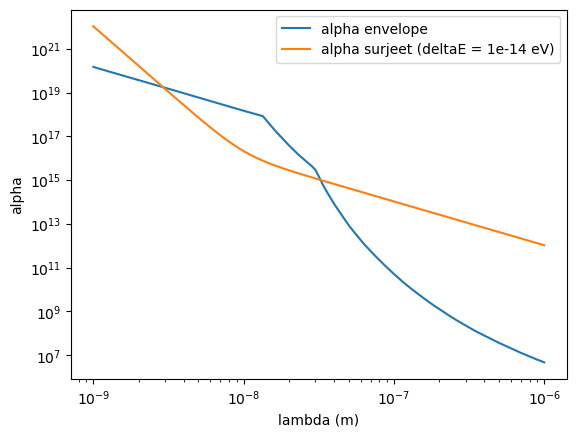

In [3]:


plt.loglog(lambda_min, alpha_min, label='alpha envelope')
plt.loglog(lambda_min, alpha_sj, label='alpha surjeet (deltaE = 1e-14 eV)')


plt.xlabel('lambda (m)')
plt.ylabel('alpha')
plt.legend()
plt.show()

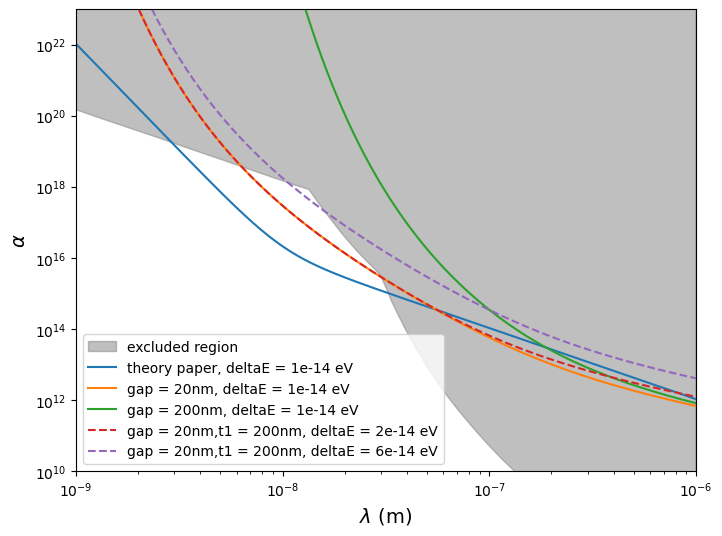

In [6]:
import numpy as np

plt.figure(figsize=(8, 6))
def alpha_func(lam, deltaE_min=1e-14, C=1e-7, t1=400e-9, t2=200e-9, d=20e-9,dilution = True):
    # C = 2*pi*g*n2
    # g: coupling *
    # n2: attractor nuclear density 
    
    shape = lam**3/t1 * np.exp(-d / lam) * (1 - np.exp(-t1 / lam)) * (1 - np.exp(-t2 / lam))
    alpha = deltaE_min / (C * shape)
    return alpha

#plt.loglog(lambda_min, alpha_min, label='existing limits')
plt.fill_between(lambda_min, alpha_min, 1e30, color='gray', alpha=0.5, label='excluded region')
plt.loglog(lambda_min, alpha_sj, label='theory paper, deltaE = 1e-14 eV')


plt.loglog(lambda_min, alpha_func(lambda_min,deltaE_min=1e-14, C=1e-13, t1=400e-9, t2=200e-9, d=20e-9), label='gap = 20nm, deltaE = 1e-14 eV')
plt.loglog(lambda_min, alpha_func(lambda_min, deltaE_min=1e-14, C=1e-13, t1=400e-9, t2=200e-9, d=200e-9), label='gap = 200nm, deltaE = 1e-14 eV')
plt.loglog(lambda_min, alpha_func(lambda_min,deltaE_min=2e-14, C=1e-13, t1=200e-9, t2=200e-9, d=20e-9), label='gap = 20nm,t1 = 200nm, deltaE = 2e-14 eV', linestyle='dashed')
plt.loglog(lambda_min, alpha_func(lambda_min,deltaE_min=6e-14, C=1e-13, t1=400e-9, t2=200e-9, d=20e-9), label='gap = 20nm,t1 = 200nm, deltaE = 6e-14 eV', linestyle='dashed')
plt.legend()

plt.ylim(1e10,1e23)
plt.xlim(1e-9, 1e-6)
plt.xlabel(r'$\lambda$ (m)',fontsize=14)
plt.ylabel(r'$\alpha$',fontsize=14)
plt.show()


In [5]:
al1 = alpha_func(r, t1=400e-9, t2=200e-9, d=20e-9)
al2 = alpha_func(r, t1=400e-9, t2=200e-9, d=20e-9,dilution=False)

plt.loglog(r, al1/al2, label='alpha with dilution d=20nm')
plt.ylim(0.5,1e2)
plt.axvline(50e-9)

NameError: name 'r' is not defined